In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

In [3]:
df=pd.read_csv("airlines_flights_data.csv")

In [4]:
df

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,Duration(minutes),days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,130,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,140,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,130,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,135,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,140,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,605,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,625,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,830,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,600,49,81585


In [5]:
df.rename(columns={'Duration(minutes)': 'duration'}, inplace=True)

In [6]:
df.drop('index', axis=1, inplace=True)

In [7]:
df = df.drop_duplicates()

In [8]:
df['stops'] = df['stops'].replace({
    'zero': 0,
    'one': 1,
    'two_or_more': 2
})

C:\Users\VISHAL BOTADARA\AppData\Local\Temp\ipykernel_29132\3739732346.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['stops'] = df['stops'].replace({


In [9]:
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

    airline   flight source_city departure_time  stops   arrival_time  \
0  SpiceJet  SG-8709       Delhi        Evening      0          Night   
1  SpiceJet  SG-8157       Delhi  Early_Morning      0        Morning   
2   AirAsia   I5-764       Delhi  Early_Morning      0  Early_Morning   
3   Vistara   UK-995       Delhi        Morning      0      Afternoon   
4   Vistara   UK-963       Delhi        Morning      0        Morning   

  destination_city    class  duration  days_left  price  
0           Mumbai  Economy       130          1   5953  
1           Mumbai  Economy       140          1   5953  
2           Mumbai  Economy       130          1   5956  
3           Mumbai  Economy       135          1   5955  
4           Mumbai  Economy       140          1   5955  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   air

In [10]:
# ==============================
# Step 1: Import Libraries
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor


# ==============================
# Step 2: Data Preprocessing
# ==============================

# Copy dataset
df_encoded = df.copy()

# Convert categorical to numeric
for col in df_encoded.select_dtypes(include=['object', 'category']).columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# Define features and target
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data Preprocessing Completed\n")


# ==============================
# Step 3: Decision Tree Model
# ==============================

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

dt_r2 = r2_score(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print("===== Decision Tree =====")
print("R² Score:", dt_r2)
print("RMSE:", dt_rmse)


# ==============================
# Step 4: Random Forest Model
# ==============================

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("\n===== Random Forest =====")
print("R² Score:", rf_r2)
print("RMSE:", rf_rmse)


# ==============================
# Step 5: XGBoost Model
# ==============================

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

xgb_r2 = r2_score(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("\n===== XGBoost =====")
print("R² Score:", xgb_r2)
print("RMSE:", xgb_rmse)


# ==============================
# Step 6: Comparison Table
# ==============================

results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'R2 Score': [dt_r2, rf_r2, xgb_r2],
    'RMSE': [dt_rmse, rf_rmse, xgb_rmse]
})

print("\n===== Model Comparison =====")
print(results)


# ==============================
# Step 7: Best Model Selection
# ==============================

best_model = results.sort_values(by='R2 Score', ascending=False).iloc[0]

print("\n===== Best Model =====")
print(best_model)

Data Preprocessing Completed

===== Decision Tree =====
R² Score: 0.9829133634050944
RMSE: 2967.803612031468

===== Random Forest =====
R² Score: 0.9895738493999647
RMSE: 2318.295886179683

===== XGBoost =====
R² Score: 0.9749143719673157
RMSE: 3595.9959677396746

===== Model Comparison =====
           Model  R2 Score         RMSE
0  Decision Tree  0.982913  2967.803612
1  Random Forest  0.989574  2318.295886
2        XGBoost  0.974914  3595.995968

===== Best Model =====
Model       Random Forest
R2 Score         0.989574
RMSE          2318.295886
Name: 1, dtype: object


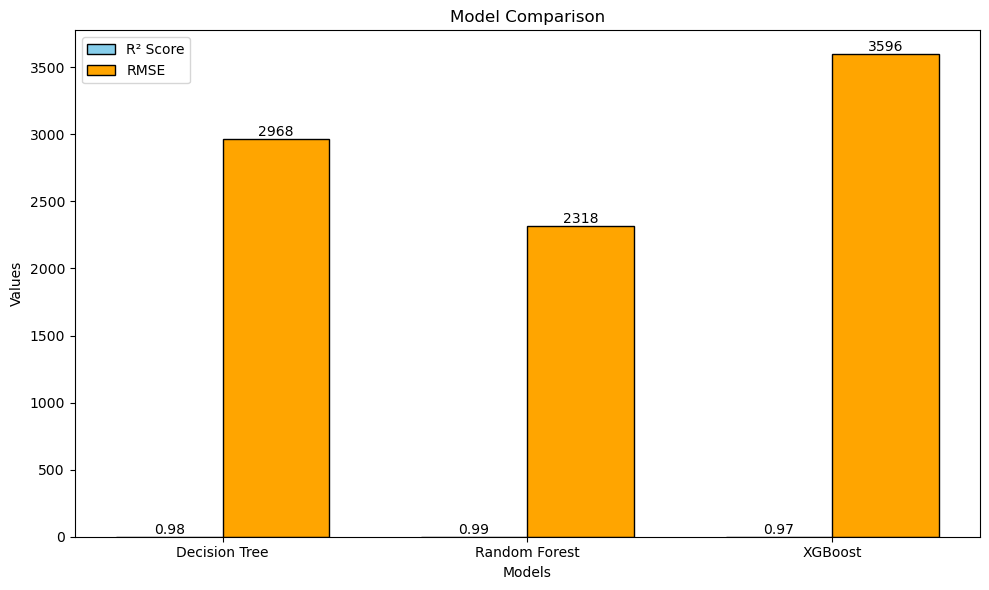

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Data (already computed)
# -----------------------------
models = results['Model']
r2_scores = results['R2 Score']
rmse_scores = results['RMSE']

# -----------------------------
# Create Figure
# -----------------------------
plt.figure(figsize=(10,6))

x = np.arange(len(models))
width = 0.35

# Bars
bars1 = plt.bar(x - width/2, r2_scores, width, label='R² Score', color='skyblue', edgecolor='black')
bars2 = plt.bar(x + width/2, rmse_scores, width, label='RMSE', color='orange', edgecolor='black')

# Labels
plt.xlabel("Models")
plt.ylabel("Values")
plt.title("Model Comparison")

plt.xticks(x, models)

# Add values on bars
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{bar.get_height():.2f}', ha='center', va='bottom')

for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f'{bar.get_height():.0f}', ha='center', va='bottom')

# Legend
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
# Styled Table
styled_table = results.style\
    .background_gradient(cmap='viridis')\
    .set_properties(**{
        'border': '1px solid black',
        'text-align': 'center'
    })\
    .set_caption("Model Comparison Table")

styled_table

,Model,R2 Score,RMSE
0,Decision Tree,0.982913,2967.803612
1,Random Forest,0.989574,2318.295886
2,XGBoost,0.974914,3595.995968


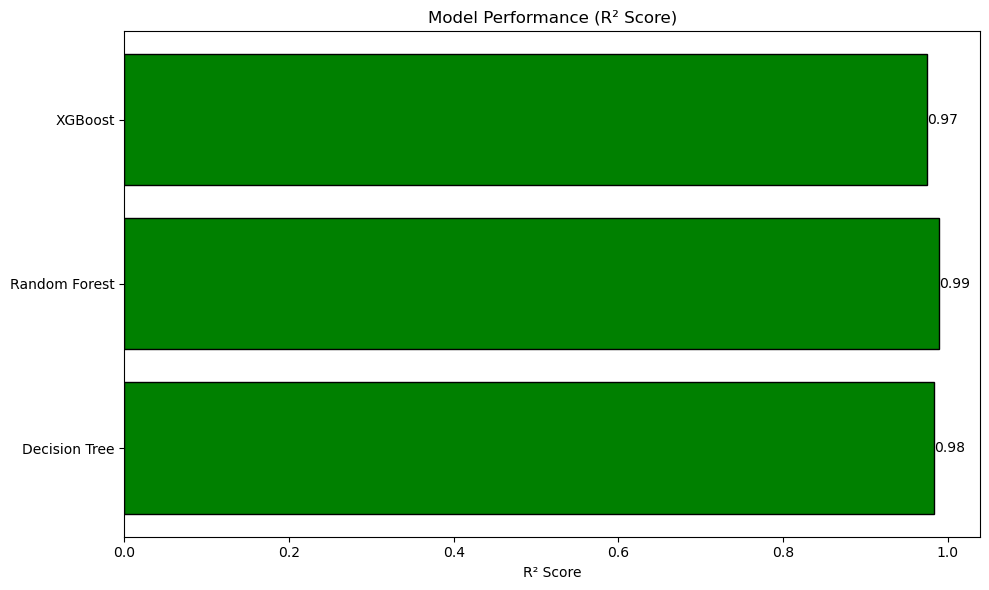

In [13]:
plt.figure(figsize=(10,6))

plt.barh(models, r2_scores, color='green', edgecolor='black')
plt.xlabel("R² Score")
plt.title("Model Performance (R² Score)")

# Values
for i, v in enumerate(r2_scores):
    plt.text(v, i, f"{v:.2f}", va='center')

plt.tight_layout()
plt.show()

In [14]:
# Residuals
res_dt = y_test - y_pred_dt
res_rf = y_test - y_pred_rf
res_xgb = y_test - y_pred_xgb

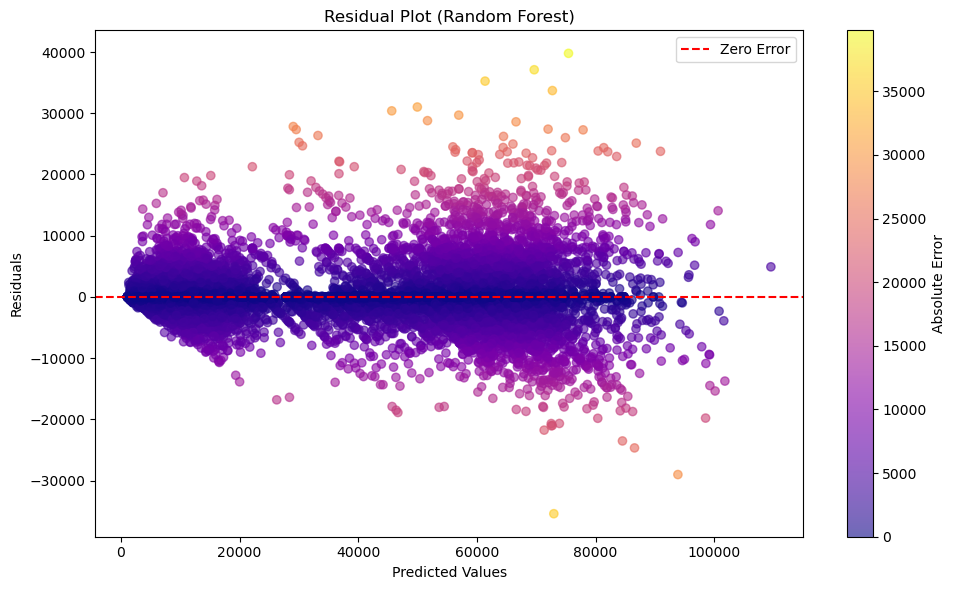

In [16]:
# =========================
# 1. Residual Plot
# =========================
plt.figure(figsize=(10,6))

plt.scatter(y_pred_rf, res_rf, 
            c=np.abs(res_rf), cmap='plasma', alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--', label='Zero Error')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Random Forest)")

cbar = plt.colorbar()
cbar.set_label("Absolute Error")

plt.legend()
plt.tight_layout()
plt.show()


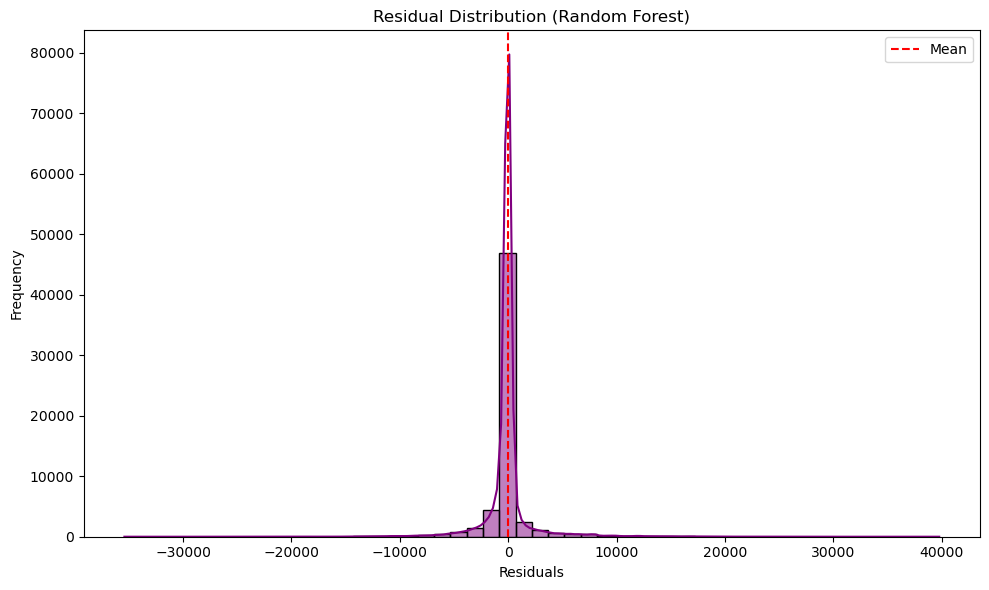

In [17]:
# =========================
# 2. Residual Distribution
# =========================
plt.figure(figsize=(10,6))

sns.histplot(res_rf, bins=50, kde=True, 
             color='purple', edgecolor='black')

plt.axvline(res_rf.mean(), color='red', linestyle='--', label='Mean')

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution (Random Forest)")

plt.legend()
plt.tight_layout()
plt.show()

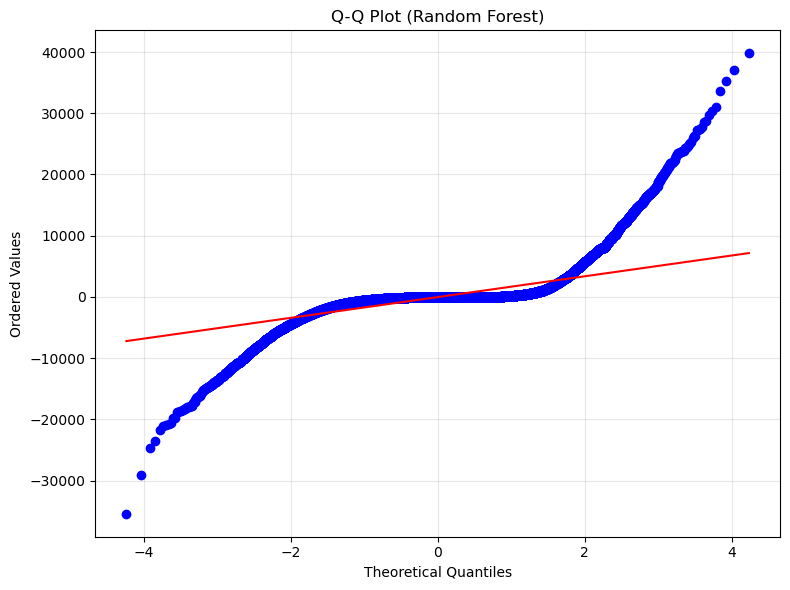

In [18]:
# =========================
# 3. Q-Q Plot
# =========================
plt.figure(figsize=(8,6))

stats.probplot(res_rf, dist="norm", plot=plt)

# Styling
plt.gca().get_lines()[0].set_markerfacecolor('blue')
plt.gca().get_lines()[1].set_color('red')

plt.title("Q-Q Plot (Random Forest)")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Ordered Values")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

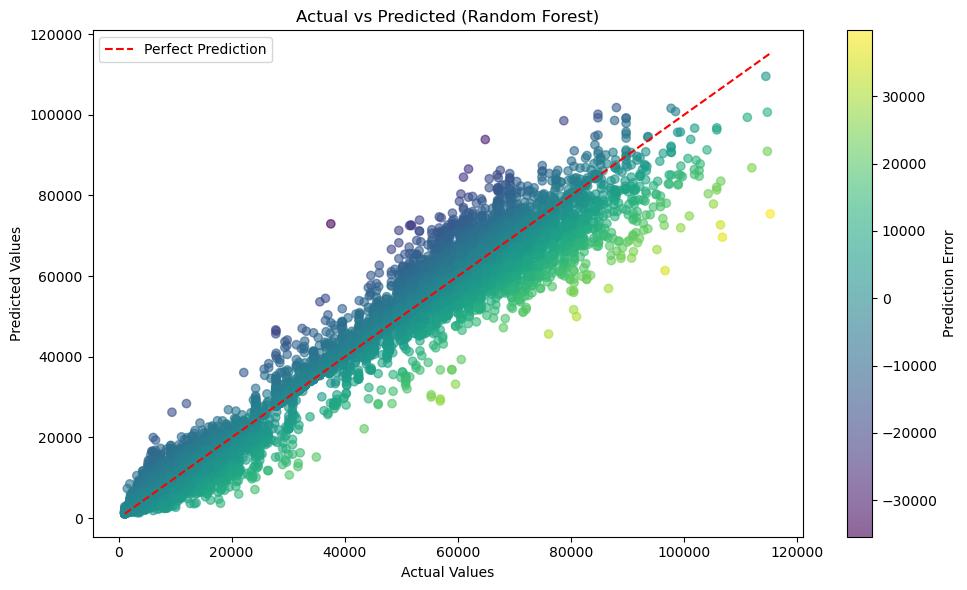

In [19]:
# =========================
# 4. Actual vs Predicted
# =========================
plt.figure(figsize=(10,6))

errors = y_test - y_pred_rf

scatter = plt.scatter(
    y_test, y_pred_rf,
    c=errors,
    cmap='viridis',
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red', linestyle='--',
    label='Perfect Prediction'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Random Forest)")

cbar = plt.colorbar(scatter)
cbar.set_label("Prediction Error")

plt.legend()
plt.tight_layout()
plt.show()

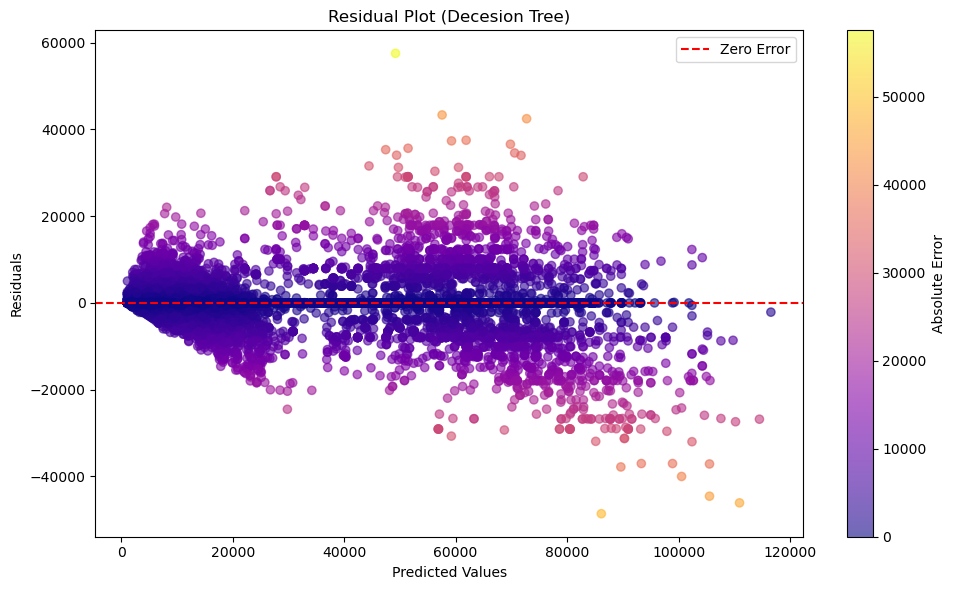

In [21]:
# =========================
# 1. Residual Plot
# =========================
plt.figure(figsize=(10,6))

plt.scatter(y_pred_dt, res_dt, 
            c=np.abs(res_dt), cmap='plasma', alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--', label='Zero Error')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Decesion Tree)")

cbar = plt.colorbar()
cbar.set_label("Absolute Error")

plt.legend()
plt.tight_layout()
plt.show()

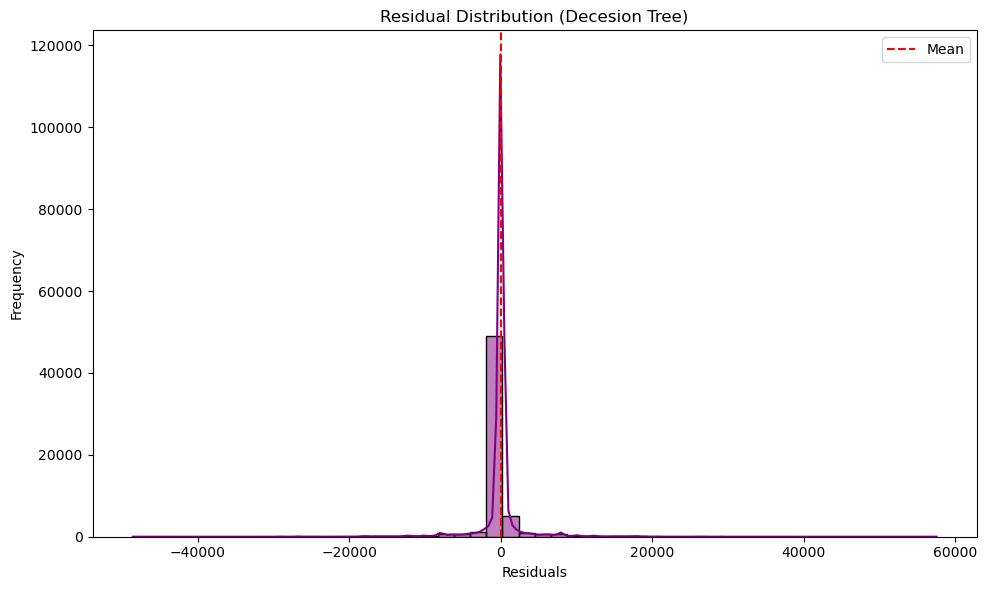

In [22]:
# =========================
# 2. Residual Distribution
# =========================
plt.figure(figsize=(10,6))

sns.histplot(res_dt, bins=50, kde=True, 
             color='purple', edgecolor='black')

plt.axvline(res_dt.mean(), color='red', linestyle='--', label='Mean')

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution (Decesion Tree)")

plt.legend()
plt.tight_layout()
plt.show()

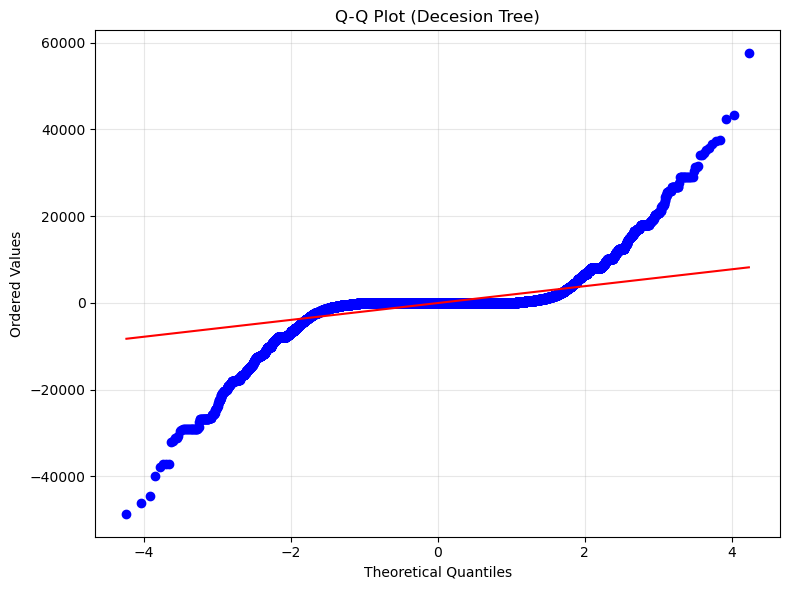

In [23]:
# =========================
# 3. Q-Q Plot
# =========================
plt.figure(figsize=(8,6))

stats.probplot(res_dt, dist="norm", plot=plt)

# Styling
plt.gca().get_lines()[0].set_markerfacecolor('blue')
plt.gca().get_lines()[1].set_color('red')

plt.title("Q-Q Plot (Decesion Tree)")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Ordered Values")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

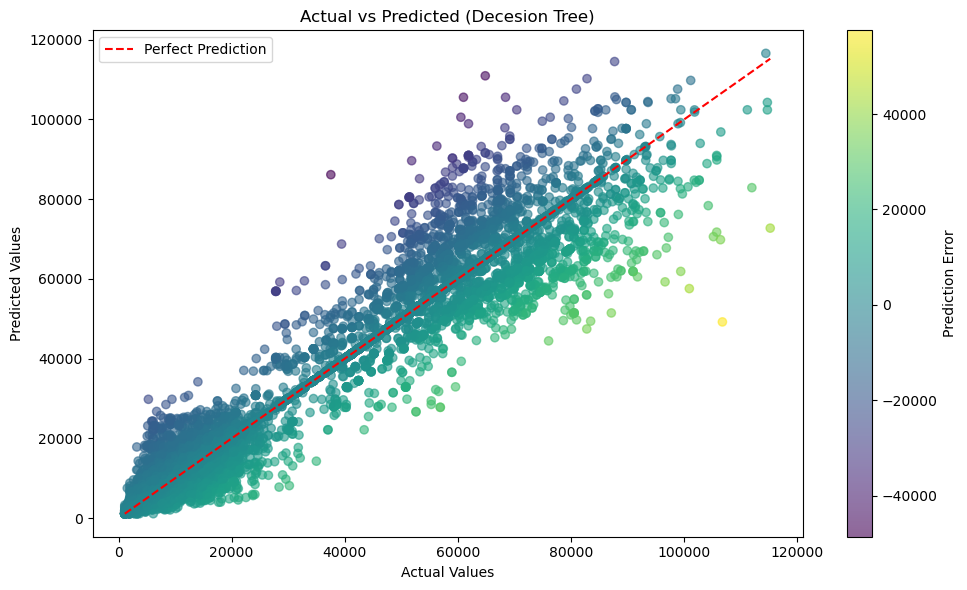

In [24]:
# =========================
# 4. Actual vs Predicted
# =========================
plt.figure(figsize=(10,6))

errors = y_test - y_pred_dt

scatter = plt.scatter(
    y_test, y_pred_dt,
    c=errors,
    cmap='viridis',
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red', linestyle='--',
    label='Perfect Prediction'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Decesion Tree)")

cbar = plt.colorbar(scatter)
cbar.set_label("Prediction Error")

plt.legend()
plt.tight_layout()
plt.show()

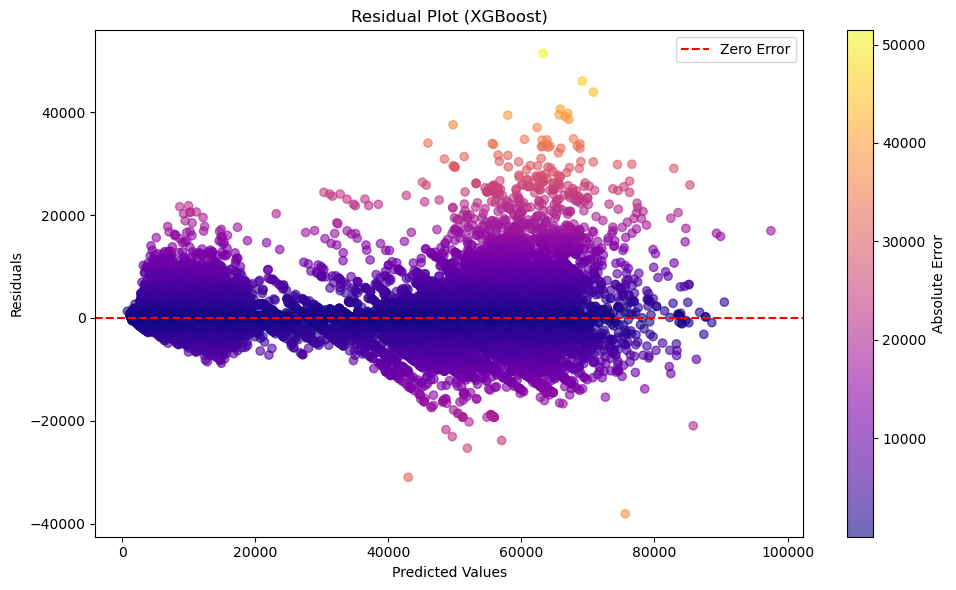

In [25]:
# =========================
# 1. Residual Plot
# =========================
plt.figure(figsize=(10,6))

plt.scatter(y_pred_xgb, res_xgb, 
            c=np.abs(res_xgb), cmap='plasma', alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--', label='Zero Error')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot (XGBoost)")

cbar = plt.colorbar()
cbar.set_label("Absolute Error")

plt.legend()
plt.tight_layout()
plt.show()

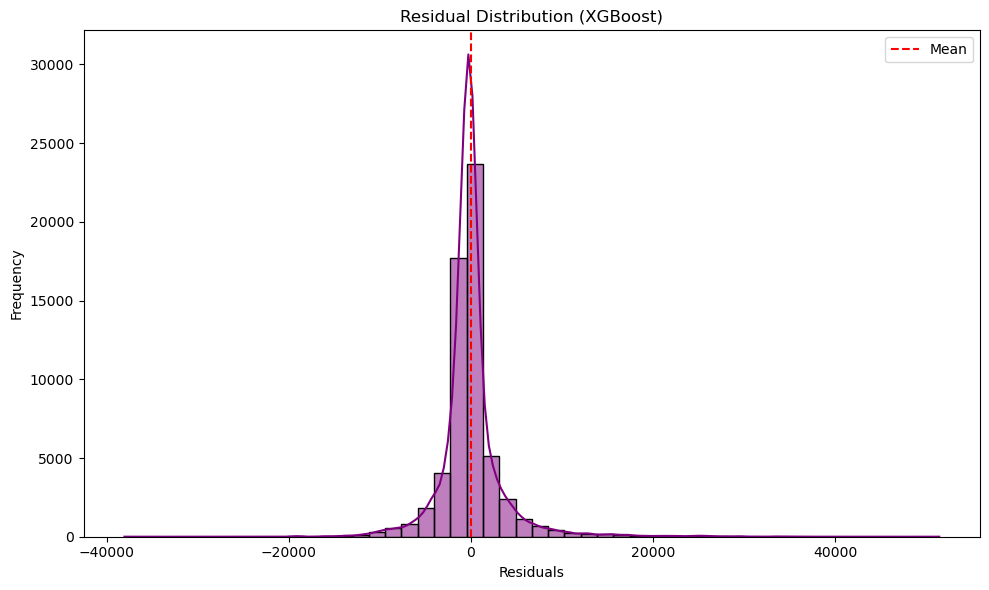

In [26]:
# =========================
# 2. Residual Distribution
# =========================
plt.figure(figsize=(10,6))

sns.histplot(res_xgb, bins=50, kde=True, 
             color='purple', edgecolor='black')

plt.axvline(res_dt.mean(), color='red', linestyle='--', label='Mean')

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution (XGBoost)")

plt.legend()
plt.tight_layout()
plt.show()

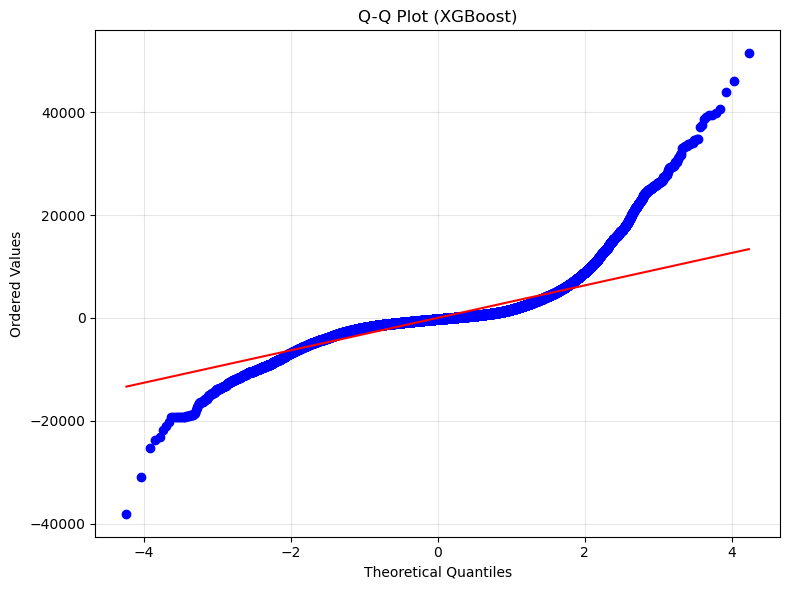

In [27]:
# =========================
# 3. Q-Q Plot
# =========================
plt.figure(figsize=(8,6))

stats.probplot(res_xgb, dist="norm", plot=plt)

# Styling
plt.gca().get_lines()[0].set_markerfacecolor('blue')
plt.gca().get_lines()[1].set_color('red')

plt.title("Q-Q Plot (XGBoost)")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Ordered Values")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

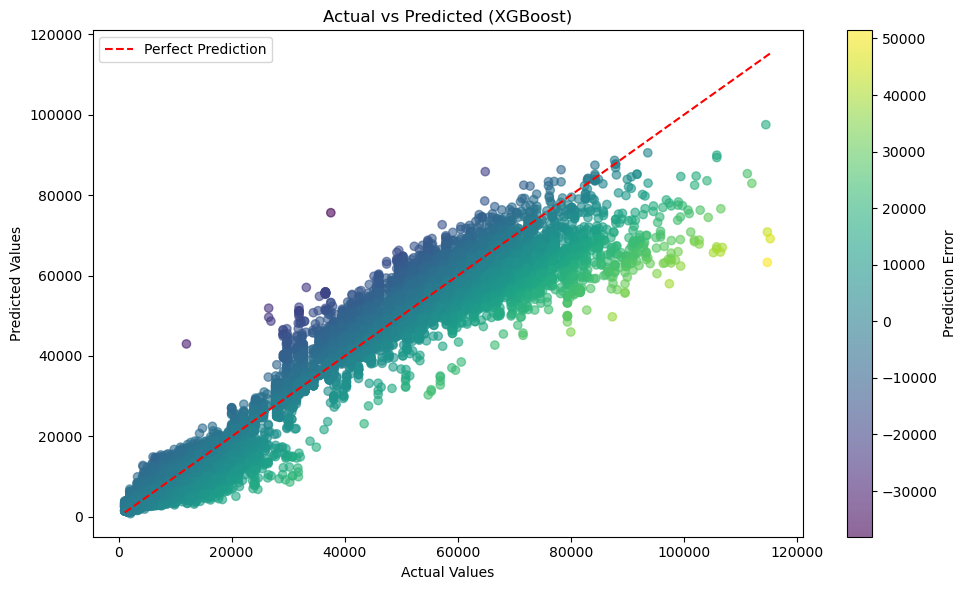

In [28]:
# =========================
# 4. Actual vs Predicted
# =========================
plt.figure(figsize=(10,6))

errors = y_test - y_pred_xgb

scatter = plt.scatter(
    y_test, y_pred_xgb,
    c=errors,
    cmap='viridis',
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red', linestyle='--',
    label='Perfect Prediction'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (XGBoost)")

cbar = plt.colorbar(scatter)
cbar.set_label("Prediction Error")

plt.legend()
plt.tight_layout()
plt.show()